# 🔮 Chronos-Demo: Rossmann-Umsatzprognose
### Vom Zero-Shot-Duell zum Panel-Showdown mit Kovariaten

Roter Faden dieses Notebooks (= Ablauf des Vortrags):

| Kapitel | Frage | Duell |
|---|---|---|
| **1** Daten | Wie sehen die Rossmann-Daten aus? | *(kein Duell – Vorbereitung)* |
| **2** Duell, Runde 1 | Chronos zero-shot vs. einfacher Prophet | Chronos naiv (Nullen) ⚔️ Prophet einfach |
| **3** Duell, Runde 2 | Wie gibt man Chronos die Schließtage? | Vorentscheid NaN ⚔️ Nullen ⚔️ kompakt, dann Sieger ⚔️ Prophet |
| **4** Stellschrauben | Kontext, Horizont, Modellgröße | Chronos-interne Duelle (u. a. tiny ⚔️ mini ⚔️ small ⚔️ base) |
| **5** Chronos-2 | Univariat → Kovariate → Panel (alle Filialen) | **Finale:** Chronos-2 Panel + Promo ⚔️ Prophet voll (Feiertage + Promo) |
| **6** Grenzen | Was kann *kein* Modell? | Duell ohne Sieger: beide ⚔️ Corona-Schock |

Datensatz: [Rossmann Store Sales](https://www.kaggle.com/c/rossmann-store-sales) – Tagesumsätze von 1.115 Drogerie-Filialen, 2013–2015.


## 🧭 Für Einsteiger: Lesehilfe & Glossar

**Die wichtigste Idee vorweg – *zero-shot*:** Chronos ist ein **Foundation Model**, das schon auf Millionen fremder Zeitreihen gelernt hat. Wie ein Sprachmodell Sätze vervollständigt, „vervollständigt" Chronos deine Zeitreihe in die Zukunft – **ohne** sich vorher an deine Daten anzupassen. Klassische Modelle (und Prophet) lernen dagegen **pro Serie** neu (`fit()`).

**Mini-Glossar**

| Begriff | In einfachen Worten |
|:---|:---|
| **Zeitreihe** | Messwerte in zeitlicher Reihenfolge (hier: Tagesumsatz). |
| **Horizont `H`** | Wie weit in die Zukunft wir vorhersagen. |
| **`y_train` / `y_test`** | Historie zum „Füttern" / echte Werte zum Benoten. Test geht nie ins Modell. |
| **zero-shot** | Vorhersagen **ohne** Training auf deinen Daten. |
| **Kontext** | Das Stück Historie, das Chronos als Eingabe sieht. |
| **äquidistant** | Gleiche Zeitabstände zwischen den Punkten – Chronos nimmt einen festen Takt an. |
| **NaN / Maskierung** | „Wert fehlt" – Chronos überspringt solche Stellen, der Takt bleibt erhalten. |
| **Quantil / Median** | Median (50 %) = beste Einzel-Schätzung; 10–90 % = Unsicherheits-Korridor. |
| **RMSE / MAE / MAPE** | Fehlermaße (kleiner = besser), MAPE in %. |
| **Kovariate** | Zusatz-Info, die den Umsatz erklärt (z. B. Promo). |
| **Panel / Cross-Learning** | Mehrere Serien gemeinsam vorhersagen, sodass sie voneinander lernen. |

**Die 5 Stellschrauben für bessere Chronos-Prognosen** (in dieser Reihenfolge im Notebook):
1. **Datenaufbereitung: Schließtage als NaN maskieren** (Kap. 3) – oft die wichtigste!
2. **Kontextlänge** (Kap. 4.1)
3. **Prognosehorizont** (Kap. 4.2)
4. **Modellgröße** (Kap. 4.3)
5. **Kovariaten & Panel** (Kap. 5) – braucht die neue Generation **Chronos-2**

*(Weitere, hier nicht gezeigt: Fine-Tuning auf eigene Daten; bei den älteren t5-Varianten die Anzahl der Sample-Pfade.)*


---
## 0 · Setup *(einfach ausführen)*


In [1]:
# Einmalig installieren, falls noch nicht in der Env:
# !pip install chronos-forecasting prophet scikit-learn

import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import BaseChronosPipeline
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42); torch.manual_seed(42)

# Einheitliche Farben für das ganze Notebook:
C_CHRONOS = '#20B2AA'   # türkis  = Chronos / Bolt
C_C2      = '#0E7C7B'   # dunkel-türkis = Chronos-2
C_PROPHET = '#7B3FF2'   # lila    = Prophet
C_BAD     = '#C0392B'   # rot     = schlechte Variante
C_MID     = '#E67E22'   # orange  = mittlere Variante
print('Setup ok – torch', torch.__version__)


Setup ok – torch 2.5.1+cpu


In [2]:
# Metrik-Helfer (gleiche Logik wie in der Prophet-Demo -> Zahlen vergleichbar)
def print_metrics(y_true, y_pred, label='Modell'):
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{label:<38} RMSE={rmse:8.1f}  MAE={mae:8.1f}  MAPE={mape:5.1f}%')
    return {'label': label, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


---
## 1 · Die Daten: Filiale 25

> 🟢 **In einfachen Worten:** Wir schauen uns EINE Filiale an. Filiale 25 ist ein Normalfall: an Sonn- und Feiertagen ist zu – im Kalender stehen dort **Nullen**. Genau diese Nullen werden gleich zum Stolperstein. *(Kuriosum am Rande: Bahnhofsfilialen wie 1097 haben jeden Tag offen – die treffen wir später im Panel wieder.)*


In [3]:
# Rohdaten: eine Zeile pro Filiale UND Tag
train = pd.read_csv('../data/rossmann-store-sales/train.csv',
                    parse_dates=['Date'], low_memory=False)

store = 25   # typische Filiale: sonntags geschlossen

raw = train[train['Store'] == store].sort_values('Date').reset_index(drop=True)

# --- Sicht a) KALENDER-Reihe: JEDER Kalendertag eine Zeile (auch Schließtage) ---
cal = raw.set_index('Date')[['Sales', 'Open', 'Promo']].asfreq('D')
cal['closed'] = (cal['Open'].fillna(0) == 0) | (cal['Sales'].fillna(0) == 0)

# --- Sicht b) KOMPAKTE Reihe: nur geöffnete Tage, lückenlos hintereinander ---
df = raw[(raw['Open'] == 1) & (raw['Sales'] > 0)].reset_index(drop=True)

print(f'Filiale {store}: {len(cal)} Kalendertage, davon {int(cal["closed"].sum())} geschlossen')
print(f'Kompakte Reihe: {len(df)} Öffnungstage von {df["Date"].min().date()} bis {df["Date"].max().date()}')
df[['Date', 'Sales', 'Promo']].head()


Filiale 25: 942 Kalendertage, davon 192 geschlossen
Kompakte Reihe: 750 Öffnungstage von 2013-01-02 bis 2015-07-31


,Date,Sales,Promo
0,2013-01-02,11944,0
1,2013-01-03,10409,0
2,2013-01-04,9729,0
3,2013-01-05,8987,0
4,2013-01-07,14513,1


Train: 708 Öffnungstage | Test: 42 Öffnungstage, verteilt auf 49 Kalendertage


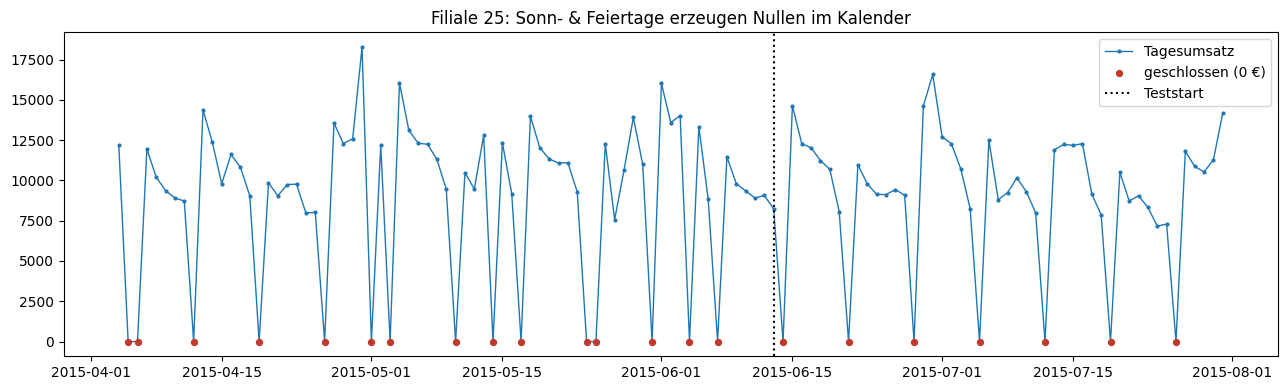

In [4]:
# Test = die letzten 42 GEÖFFNETEN Tage (~7 Wochen Geschäft)
H = 42
y = df['Sales'].to_numpy(dtype=float)
y_train, y_test = y[:-H], y[-H:]
dates_train, dates_test = df['Date'].iloc[:-H], df['Date'].iloc[-H:]

# Dasselbe Testfenster in Kalender-Sicht (enthält zusätzlich die Schließtage):
test_start = dates_test.iloc[0]
cal_hist, cal_test = cal[cal.index < test_start], cal[cal.index >= test_start]
H_cal    = len(cal_test)                                    # Kalendertage im Testfenster
open_pos = np.where(~cal_test['closed'].to_numpy())[0]      # wo liegen die Öffnungstage?
assert len(open_pos) == H

print(f'Train: {len(y_train)} Öffnungstage | Test: {H} Öffnungstage, verteilt auf {H_cal} Kalendertage')

# Blick auf die letzten ~16 Wochen in Kalender-Sicht:
last = cal.iloc[-(H_cal + 70):]
plt.figure(figsize=(13, 4))
plt.plot(last.index, last['Sales'].fillna(0), color='C0', lw=1, marker='.', ms=4, label='Tagesumsatz')
closed_days = last[last['closed']]
plt.scatter(closed_days.index, np.zeros(len(closed_days)), color=C_BAD, s=18, zorder=3,
            label='geschlossen (0 €)')
plt.axvline(test_start, color='k', ls=':', label='Teststart')
plt.title(f'Filiale {store}: Sonn- & Feiertage erzeugen Nullen im Kalender')
plt.legend(); plt.tight_layout(); plt.show()


---
## 2 · Duell, Runde 1: Chronos zero-shot vs. einfacher Prophet

> 🟢 **In einfachen Worten:** Beide Modelle bekommen NUR die Umsatzhistorie – kein Promo-Wissen, keine Feiertagsliste. Prophet trainiert auf der Filiale (`fit()`), Chronos sagt zero-shot vorher. Wir füttern Chronos erstmal *naiv*: einfach alle Kalendertage, Schließtage als 0 €.


In [5]:
# Chronos-Bolt laden (beim 1. Mal Download, danach aus dem Cache). Läuft auf CPU.
pipe = BaseChronosPipeline.from_pretrained('amazon/chronos-bolt-small', device_map='cpu')

# NAIVER Versuch: alle Kalendertage, Schließtage als 0 in der Zahlenfolge.
ctx_cal0 = cal_hist['Sales'].fillna(0).to_numpy(dtype=float)
q, _ = pipe.predict_quantiles(inputs=torch.tensor(ctx_cal0, dtype=torch.float32),
                              prediction_length=H_cal, quantile_levels=[0.1, 0.5, 0.9])
# Die Prognose liegt auf KALENDERTAGEN 
med_naiv = q[0, :, 1].numpy()[open_pos]
m_naiv = print_metrics(y_test, med_naiv, 'Chronos naiv (Kalender, Schließtage=0)')


Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Chronos naiv (Kalender, Schließtage=0) RMSE=  1830.6  MAE=  1410.7  MAPE= 12.9%


14:48:58 - cmdstanpy - INFO - Chain [1] start processing
14:48:58 - cmdstanpy - INFO - Chain [1] done processing


Chronos naiv (zero-shot)               RMSE=  1830.6  MAE=  1410.7  MAPE= 12.9%
Prophet einfach (Trend+Saison, fit)    RMSE=  1824.0  MAE=  1362.2  MAPE= 12.3%


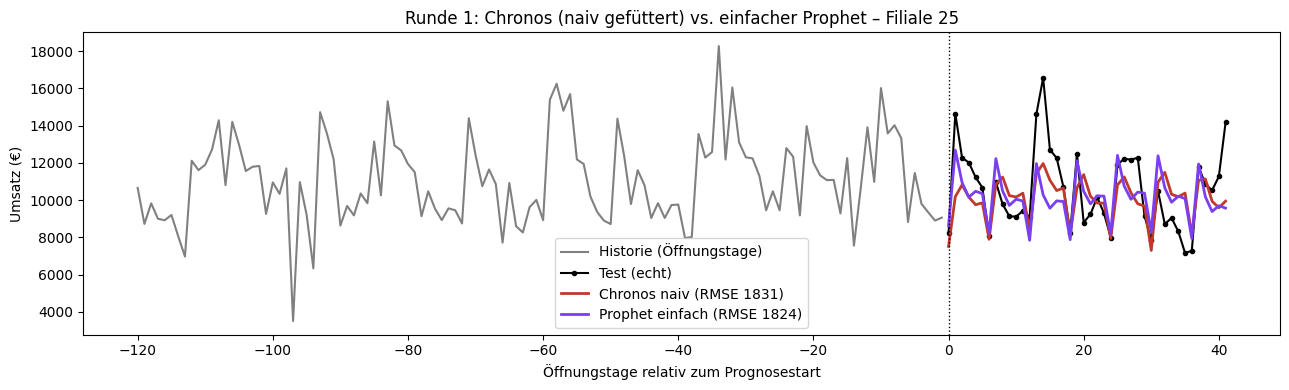

In [6]:
# Einfacher Prophet: nur Trend + Wochen-/Jahressaison, KEINE Extras.
# Prophet arbeitet mit echten Datumswerten und kommt daher von allein mit Schließtagen klar
# (die fehlen einfach in der Trainingstabelle).
from prophet import Prophet

pdf_train = pd.DataFrame({'ds': dates_train.values, 'y': y_train})
m_p1 = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m_p1.fit(pdf_train)                                   # <- hier lernt Prophet die Filiale
fc_p1 = m_p1.predict(pd.DataFrame({'ds': dates_test.values}))
pred_prophet_m1 = fc_p1['yhat'].to_numpy()

m_chronos = print_metrics(y_test, med_naiv,        'Chronos naiv (zero-shot)')
m_prophet = print_metrics(y_test, pred_prophet_m1, 'Prophet einfach (Trend+Saison, fit)')

x_hist = np.arange(-120, 0); x_fc = np.arange(0, H)
plt.figure(figsize=(13, 4))
plt.plot(x_hist, y_train[-120:], color='gray', label='Historie (Öffnungstage)')
plt.plot(x_fc, y_test, color='black', marker='.', label='Test (echt)')
plt.plot(x_fc, med_naiv, color=C_BAD, lw=2, label=f'Chronos naiv (RMSE {m_chronos["RMSE"]:.0f})')
plt.plot(x_fc, pred_prophet_m1, color=C_PROPHET, lw=2, label=f'Prophet einfach (RMSE {m_prophet["RMSE"]:.0f})')
plt.axvline(0, color='k', ls=':', lw=1)
plt.title(f'Runde 1: Chronos (naiv gefüttert) vs. einfacher Prophet – Filiale {store}')
plt.xlabel('Öffnungstage relativ zum Prognosestart'); plt.ylabel('Umsatz (€)')
plt.legend(); plt.tight_layout(); plt.show()


**Was sehen wir?** Prophet liegt **hauchdünn** vorn – RMSE 1824 vs. 1831 (< 0,5 %), MAE 1362 vs. 1411, MAPE 12,3 % vs. 12,9 %. Alle drei Metriken zeigen in dieselbe Richtung, aber der Abstand ist so klein, dass er auf einer anderen Filiale kippen kann. Liegt das am Modell? **Nein – an der Fütterung.** Prophet kennt den Kalender („Sonntag = zu") von Haus aus. Chronos dagegen sieht **nur die nackte Zahlenfolge, kein Datum** – und die künstlichen Nullen verfälschen das Muster. Das reparieren wir jetzt.


---
## 3 · Stellschraube #1: Wie füttert man Chronos die Schließtage?

> 🟢 **In einfachen Worten:** Chronos behandelt die Eingabe als gleichmäßig getaktete Zahlenfolge und schaut **allein auf die Werte, nicht auf das Datum**. Drei Arten, dieselbe Filiale zu füttern:
> - **Kalender + 0:** jeder Tag ein Wert, Schließtage = 0 → falsche Nullen im Muster
> - **Kalender + NaN:** Schließtage als „fehlt" markiert → Chronos **maskiert** sie, der 7-Tage-Takt bleibt erhalten
> - **kompakt:** Schließtage herausgeschnitten, Öffnungstage direkt hintereinander → keine Nullen, aber der Takt **verzerrt** (eine Woche = mal 6, mal 5 Schritte)
>
> Alle drei werden auf **denselben 42 Öffnungstagen** benotet. Welche gewinnt?


Kalender + 0                           RMSE=  1830.6  MAE=  1410.7  MAPE= 12.9%
Kalender + NaN                         RMSE=  1685.3  MAE=  1277.3  MAPE= 12.0%
kompakt                                RMSE=  1961.5  MAE=  1583.9  MAPE= 16.5%


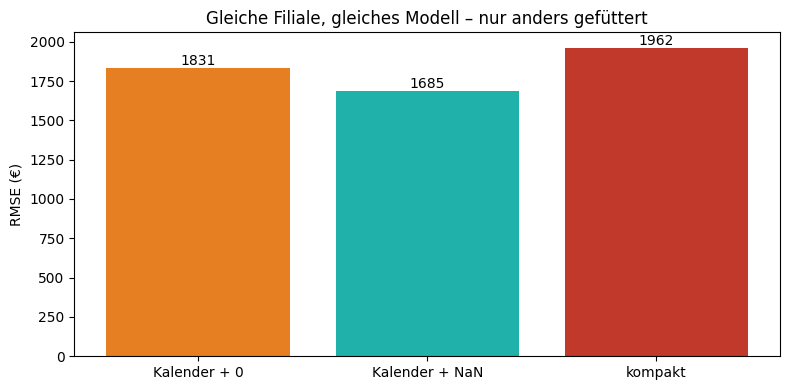

In [7]:
medians = {'Kalender + 0': med_naiv}                       # Variante A von oben

# Variante B: Schließtage = NaN (Chronos maskiert fehlende Werte)
ctx_nan = cal_hist['Sales'].where(~cal_hist['closed']).to_numpy(dtype=float)
q, _ = pipe.predict_quantiles(inputs=torch.tensor(ctx_nan, dtype=torch.float32),
                              prediction_length=H_cal, quantile_levels=[0.1, 0.5, 0.9])
medians['Kalender + NaN'] = q[0, :, 1].numpy()[open_pos]

# Variante C: kompakte Reihe (nur Öffnungstage, direkt hintereinander)
q, _ = pipe.predict_quantiles(inputs=torch.tensor(y_train, dtype=torch.float32),
                              prediction_length=H, quantile_levels=[0.1, 0.5, 0.9])
medians['kompakt'] = q[0, :, 1].numpy()

rows_eq = [print_metrics(y_test, m, name) for name, m in medians.items()]
eq = pd.DataFrame(rows_eq).set_index('label')

# Gewinner automatisch türkis, Verlierer rot einfärben:
colors = [C_CHRONOS if v == eq['RMSE'].min() else (C_BAD if v == eq['RMSE'].max() else C_MID)
          for v in eq['RMSE']]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(eq.index, eq['RMSE'], color=colors)
for i, v in enumerate(eq['RMSE']):
    ax.text(i, v, f'{v:.0f}', ha='center', va='bottom')
ax.set_ylabel('RMSE (€)'); ax.set_title('Gleiche Filiale, gleiches Modell – nur anders gefüttert')
plt.tight_layout(); plt.show()


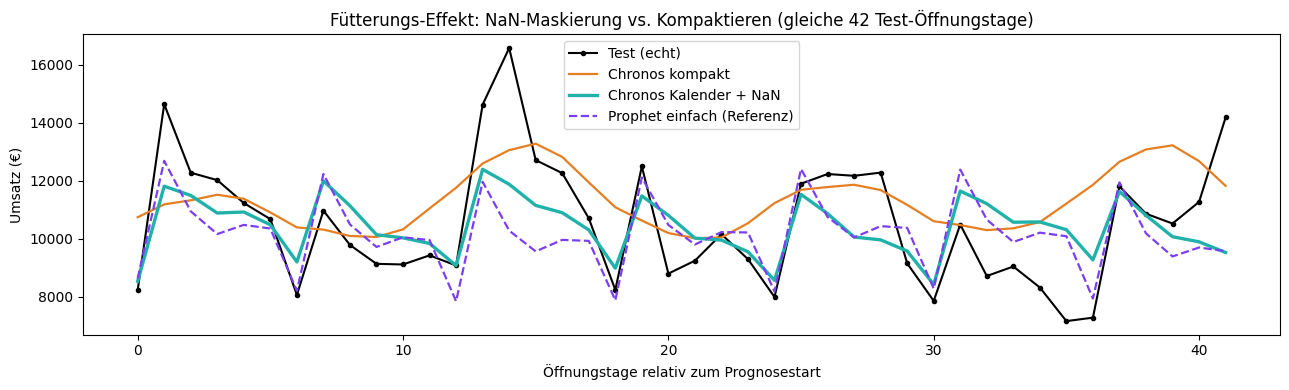

Duell, Runde 2 – jetzt richtig gefüttert:
Chronos (Kalender + NaN)               RMSE=  1685.3  MAE=  1277.3  MAPE= 12.0%
Prophet einfach (fit)                  RMSE=  1824.0  MAE=  1362.2  MAPE= 12.3%


In [8]:
# Übersichtlich: nur die zwei Chronos-Kandidaten (NaN vs. kompakt) + Prophet als Referenz.
# (Die Nullen-Variante ist im Balkendiagramm oben abgehakt.)
med_nan = medians['Kalender + NaN']
x_fc = np.arange(H)
plt.figure(figsize=(13, 4))
plt.plot(x_fc, y_test, color='black', marker='.', label='Test (echt)')
plt.plot(x_fc, medians['kompakt'], color=C_MID, lw=1.6, label='Chronos kompakt')
plt.plot(x_fc, med_nan, color=C_CHRONOS, lw=2.4, label='Chronos Kalender + NaN')
plt.plot(x_fc, pred_prophet_m1, color=C_PROPHET, lw=1.6, ls='--', label='Prophet einfach (Referenz)')
plt.title('Fütterungs-Effekt: NaN-Maskierung vs. Kompaktieren (gleiche 42 Test-Öffnungstage)')
plt.xlabel('Öffnungstage relativ zum Prognosestart'); plt.ylabel('Umsatz (€)')
plt.legend(); plt.tight_layout(); plt.show()

print('Duell, Runde 2 – jetzt richtig gefüttert:')
m_chronos_nan = print_metrics(y_test, med_nan,          'Chronos (Kalender + NaN)')
m_prophet_m1  = print_metrics(y_test, pred_prophet_m1,  'Prophet einfach (fit)')


**Was sehen wir?** Auf Filiale 25 gewinnt **Kalender + NaN** – und Kompaktieren ist hier sogar die schlechteste Variante!

**Warum?**
- **NaN-Maskierung** entfernt die falschen Nullen, **erhält aber den echten 7-Tage-Takt**: Das Wochenmuster bleibt an der richtigen Stelle, Chronos überspringt die Lücken einfach.
- **Kompaktieren** entfernt die Nullen auch – zerstört aber den Takt: Eine normale Woche wird 6 Schritte, eine Feiertagswoche 5. Das gelernte „alle 7 Schritte wiederholt sich alles" passt nicht mehr, und auch die Jahressaison wird gestaucht.
- Die **Nullen** verfälschen zwar das Niveau, lassen den 7er-Rhythmus aber wenigstens intakt – deshalb sind sie hier weniger schlimm als das Kompaktieren.

**Merksatz: Chronos liest Werte, kein Datum – Schließtage niemals als 0, sondern als NaN maskieren.** Und damit geht Runde 2 des Duells an Chronos.

> **Ab jetzt gilt im ganzen Notebook: Kalender-Reihe mit NaN an Schließtagen.**
> *(Die Rangfolge kann je Filiale/Testfenster variieren – die Nullen verlieren aber praktisch immer. Gern andere `store`-Werte testen.)*


---
## 4 · Die Stellschrauben: Was macht Chronos-Prognosen besser?

Stellschraube #1 (Schließtage als NaN) kennen wir. Jetzt drehen wir die restlichen – immer auf der NaN-Kalenderreihe, immer benotet auf denselben 42 Test-Öffnungstagen.


### 4.1 · Kontextlänge – wie viel Historie darf das Modell sehen?

> 🟢 **In einfachen Worten:** Wir geben Chronos mal wenig, mal viel Vergangenheit. Mehr ist nicht automatisch besser: Zu wenig → Jahresmuster fehlt. Sehr viel → alte, evtl. nicht mehr gültige Muster verwässern die jüngere Dynamik.


Kontext = 90 Tage                      RMSE=  2006.5  MAE=  1632.1  MAPE= 16.5%
Kontext = 180 Tage                     RMSE=  2106.2  MAE=  1745.6  MAPE= 17.9%
Kontext = 365 Tage                     RMSE=  1654.5  MAE=  1268.3  MAPE= 12.3%
Kontext = 730 Tage                     RMSE=  1686.8  MAE=  1284.4  MAPE= 12.3%
Kontext = 893 Tage                     RMSE=  1685.3  MAE=  1277.3  MAPE= 12.0%


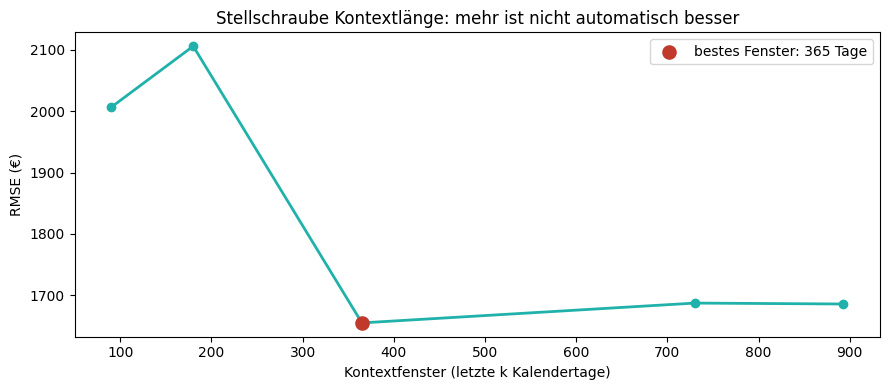

In [9]:
CONTEXT_WINDOWS = [90, 180, 365, 730, len(ctx_nan)]        # in Kalendertagen

results_ctx = []
for k in CONTEXT_WINDOWS:
    ctx = ctx_nan[-k:]                      # nur die letzten k Kalendertage
    q, _ = pipe.predict_quantiles(inputs=torch.tensor(ctx, dtype=torch.float32),
                                  prediction_length=H_cal, quantile_levels=[0.5])
    med = q[0, :, 0].numpy()[open_pos]
    results_ctx.append({**print_metrics(y_test, med, f'Kontext = {k} Tage'), 'Tage': k})

ctx_summary = pd.DataFrame(results_ctx).set_index('label')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ctx_summary['Tage'], ctx_summary['RMSE'], marker='o', color=C_CHRONOS, lw=2)
best = ctx_summary['RMSE'].idxmin()
ax.scatter([ctx_summary.loc[best, 'Tage']], [ctx_summary.loc[best, 'RMSE']], color=C_BAD, s=90,
           zorder=3, label=f'bestes Fenster: {int(ctx_summary.loc[best, "Tage"])} Tage')
ax.set_xlabel('Kontextfenster (letzte k Kalendertage)'); ax.set_ylabel('RMSE (€)')
ax.set_title('Stellschraube Kontextlänge: mehr ist nicht automatisch besser')
ax.legend(); plt.tight_layout(); plt.show()


### 4.2 · Prognosehorizont – wie weit kann man gucken?

> 🟢 **In einfachen Worten:** Je weiter weg, desto unsicherer die Prognose. Wir zeigen das zweimal – komplett mit Rossmann-Daten:
> 1. **Lehrbuch-Bild (Fan-Chart) auf Filiale 708:** Wochenumsätze, ein halbes Jahr Horizont. Hinter „Heute" öffnen sich das 50-%- und das 80-%-Intervall wie ein Trichter.
> 2. **Backtest-Beleg auf Filiale 25:** von 12 Startpunkten aus prognostiziert wächst der mittlere Fehler mit der **Lead Time** (wie viele Tage ein Tag „voraus" lag).
>
> ⚠️ **Warum Filiale 708 und nicht unsere Filiale 25?** Der Trichter entsteht nur bei Reihen mit **Trend**: Dort summieren sich mögliche Abweichungen über die Zeit auf. Filiale 25 ist **stabil und saisonal** (Trend ≈ −3 %/Jahr): Nächste Woche sieht aus wie diese Woche – die Unsicherheit **sättigt** nach wenigen Tagen, das Band bleibt gleich breit. Filiale 708 wächst dagegen um ≈ +38 %/Jahr → sichtbarer Trichter. Merksatz: *Wie schnell die Unsicherheit wächst, hängt vom Charakter der Reihe ab – nicht vom Modell.*


 Horizont (Kalendertage)  Öffnungstage   RMSE
                       7             6 1297.9
                      14            12 1165.2
                      28            24 1500.7
                      49            42 1685.3


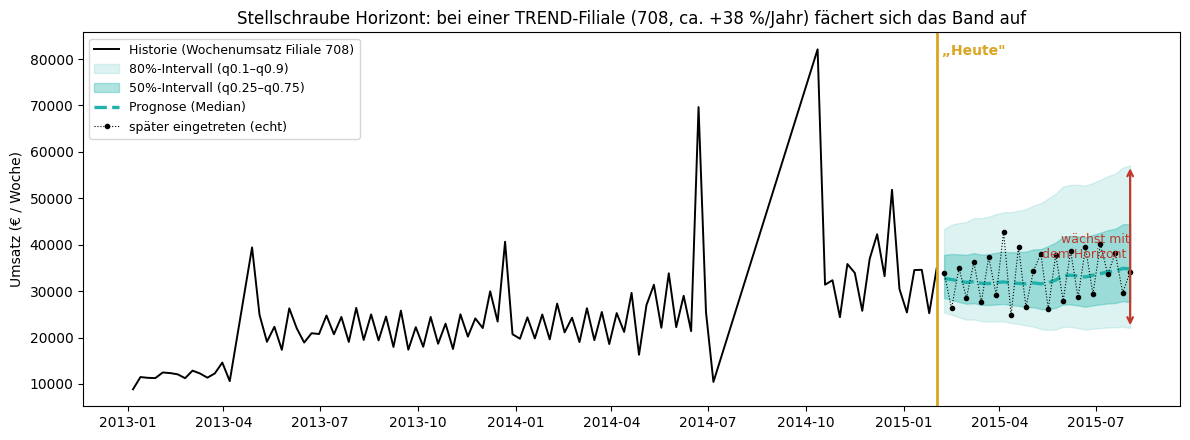

Intervallbreite (q0.9−q0.1): Woche 1: 18,021 €  ->  Woche 26: 35,030 €


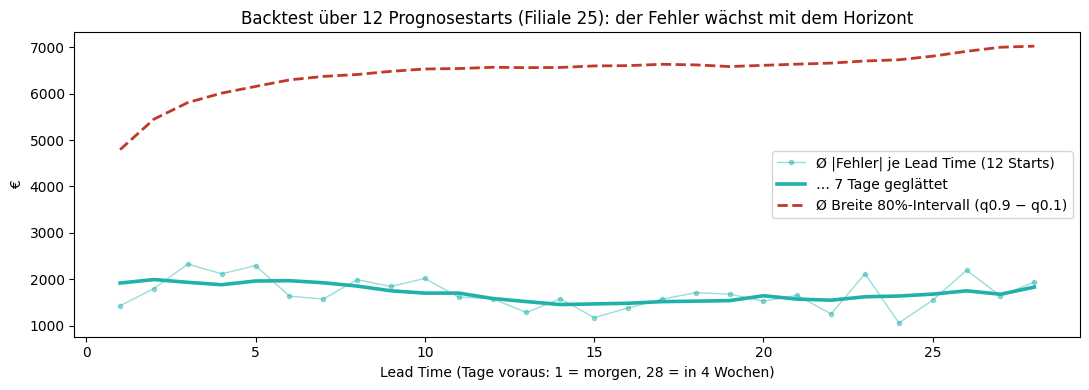

In [10]:
# --- (a) Zahlen-Beleg: RMSE je Horizont (kurz prognostizieren = kleinerer Fehler) ---
horizons = [7, 14, 28, H_cal]                              # in Kalendertagen
rows_h = []
for h in horizons:
    q, _ = pipe.predict_quantiles(inputs=torch.tensor(ctx_nan, dtype=torch.float32),
                                  prediction_length=h, quantile_levels=[0.5])
    med_cal = q[0, :, 0].numpy()
    pos = open_pos[open_pos < h]
    rmse = np.sqrt(mean_squared_error(y_test[:len(pos)], med_cal[pos]))
    rows_h.append({'Horizont (Kalendertage)': h, 'Öffnungstage': len(pos), 'RMSE': rmse})
print(pd.DataFrame(rows_h).round(1).to_string(index=False))

# --- (b) Fan-Chart im Lehrbuch-Stil - mit Rossmann! Trick: eine TREND-Filiale nehmen ---
# Filiale 25 ist stabil & saisonal (Trend ca. -3 %/Jahr) -> Unsicherheit sättigt, kein Trichter.
# Filiale 708 wächst ca. +38 %/Jahr -> hier fächert sich das Band sichtbar auf.
STORE_TREND = 708
wk = (train[(train['Store'] == STORE_TREND) & (train['Open'] == 1) & (train['Sales'] > 0)]
      .set_index('Date')['Sales'].resample('W').sum())
wk = wk[wk > 0]                                             # leere Randwochen raus
H_W = 26                                                    # ein halbes Jahr vorausschauen
wk_hist, wk_test = wk.iloc[:-H_W], wk.iloc[-H_W:]

q, _ = pipe.predict_quantiles(inputs=torch.tensor(wk_hist.to_numpy(dtype=float),
                                                  dtype=torch.float32),
                              prediction_length=H_W,
                              quantile_levels=[0.1, 0.25, 0.5, 0.75, 0.9])
qw = q[0].numpy()
heute = wk_hist.index[-1]

plt.figure(figsize=(12, 4.5))
plt.plot(wk_hist.index, wk_hist.values, color='black', lw=1.4,
         label=f'Historie (Wochenumsatz Filiale {STORE_TREND})')
plt.fill_between(wk_test.index, qw[:, 0], qw[:, 4], color=C_CHRONOS, alpha=0.15,
                 label='80%-Intervall (q0.1–q0.9)')
plt.fill_between(wk_test.index, qw[:, 1], qw[:, 3], color=C_CHRONOS, alpha=0.35,
                 label='50%-Intervall (q0.25–q0.75)')
plt.plot(wk_test.index, qw[:, 2], color=C_CHRONOS, lw=2.4, ls='--', label='Prognose (Median)')
plt.plot(wk_test.index, wk_test.values, color='black', marker='.', lw=0.8, ls=':',
         label='später eingetreten (echt)')
plt.axvline(heute, color='goldenrod', lw=2)
plt.annotate('', xy=(wk_test.index[-1], qw[-1, 4]), xytext=(wk_test.index[-1], qw[-1, 0]),
             arrowprops=dict(arrowstyle='<->', color=C_BAD, lw=1.6))
plt.text(wk_test.index[-1], (qw[-1, 0] + qw[-1, 4]) / 2, 'wächst mit\ndem Horizont ',
         color=C_BAD, fontsize=9, ha='right', va='center')
plt.text(heute, plt.ylim()[1] * 0.97, ' „Heute"', color='goldenrod', va='top', fontweight='bold')
plt.title(f'Stellschraube Horizont: bei einer TREND-Filiale ({STORE_TREND}, ca. +38 %/Jahr) fächert sich das Band auf')
plt.ylabel('Umsatz (€ / Woche)'); plt.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Intervallbreite (q0.9−q0.1): Woche 1: {qw[0,4]-qw[0,0]:,.0f} €  ->  Woche {H_W}: {qw[-1,4]-qw[-1,0]:,.0f} €')

# --- (c) Backtest-Beleg auf Filiale 25: Fehler nach "Tagen voraus" (Lead Time) ---
H_LT, N_ORIGINS = 28, 12
# Abstand 23 Tage = KEIN Vielfaches von 7 -> Starts fallen auf verschiedene Wochentage,
# so mitteln sich Wochentags-Effekte heraus.
origins = np.arange(len(ctx_nan) - H_LT, 365, -23)[:N_ORIGINS]
abs_err = np.full((len(origins), H_LT), np.nan)
width   = np.full((len(origins), H_LT), np.nan)
for i, t0 in enumerate(origins):
    q, _ = pipe.predict_quantiles(inputs=torch.tensor(ctx_nan[:t0], dtype=torch.float32),
                                  prediction_length=H_LT, quantile_levels=[0.1, 0.5, 0.9])
    lo, med, hi = q[0, :, 0].numpy(), q[0, :, 1].numpy(), q[0, :, 2].numpy()
    truth = ctx_nan[t0:t0 + H_LT]                           # die "damalige Zukunft" (NaN = zu)
    mask = ~np.isnan(truth)
    abs_err[i, mask] = np.abs(truth[mask] - med[mask])
    width[i, :] = hi - lo

lead      = np.arange(1, H_LT + 1)
err_mean  = np.nanmean(abs_err, axis=0)
err_glatt = pd.Series(err_mean).rolling(7, center=True, min_periods=3).mean()

plt.figure(figsize=(11, 4))
plt.plot(lead, err_mean, color=C_CHRONOS, lw=1, alpha=0.45, marker='.',
         label='Ø |Fehler| je Lead Time (12 Starts)')
plt.plot(lead, err_glatt, color=C_CHRONOS, lw=2.6, label='… 7 Tage geglättet')
plt.plot(lead, np.nanmean(width, axis=0), color=C_BAD, lw=2, ls='--',
         label='Ø Breite 80%-Intervall (q0.9 − q0.1)')
plt.title(f'Backtest über {len(origins)} Prognosestarts (Filiale 25): der Fehler wächst mit dem Horizont')
plt.xlabel('Lead Time (Tage voraus: 1 = morgen, 28 = in 4 Wochen)'); plt.ylabel('€')
plt.legend(); plt.tight_layout(); plt.show()


### 4.3 · Modellgröße – tiny, mini, small, base

> 🟢 **In einfachen Worten:** Größere Modelle „wissen" tendenziell mehr, brauchen aber mehr Rechenzeit. Wir messen beides.

> ⚠️ **Größe ≠ Generation!** „Modellgröße bringt wenig" gilt für die Skalierung *innerhalb* einer Generation (Bolt tiny → base: RMSE 1875 → 1572, ca. −16 %). Der große Sprung zu **Chronos-2** (RMSE 1086, ca. −31 % ggü. Bolt-base) kommt dagegen NICHT von mehr Parametern: Chronos-2 hat nur **120 Mio. Parameter** (Ansari et al., Chronos-2-Paper) – *weniger* als Bolt-base (laut Hugging-Face-Modellkarte ~205 Mio.). Der Sprung kommt von Architektur (Group Attention → In-Context Learning) und Trainingsdaten – siehe Kap. 5 und Spickzettel im Anhang.


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

chronos-bolt-tiny                      RMSE=  1874.9  MAE=  1540.9  MAPE= 14.7%


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

chronos-bolt-mini                      RMSE=  1833.8  MAE=  1471.6  MAPE= 13.9%


Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

chronos-bolt-small                     RMSE=  1685.3  MAE=  1277.3  MAPE= 12.0%


Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

chronos-bolt-base                      RMSE=  1572.2  MAE=  1207.5  MAPE= 11.3%


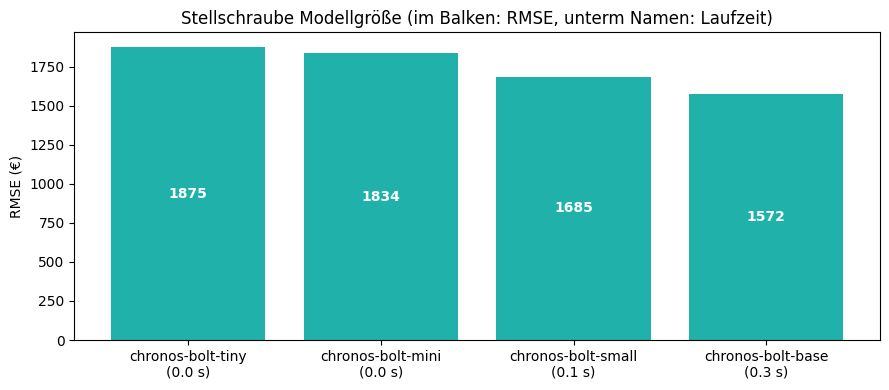

In [11]:
results_size = []
for model_id in ['amazon/chronos-bolt-tiny', 'amazon/chronos-bolt-mini',
                 'amazon/chronos-bolt-small', 'amazon/chronos-bolt-base']:
    p = BaseChronosPipeline.from_pretrained(model_id, device_map='cpu')
    t0 = time.time()
    q, _ = p.predict_quantiles(inputs=torch.tensor(ctx_nan, dtype=torch.float32),
                               prediction_length=H_cal, quantile_levels=[0.5])
    dt = time.time() - t0
    r = print_metrics(y_test, q[0, :, 0].numpy()[open_pos], model_id.split('/')[-1])
    r['Sekunden'] = round(dt, 2)
    results_size.append(r)

size_table = pd.DataFrame(results_size).set_index('label')
fig, ax = plt.subplots(figsize=(9, 4))
# Laufzeit wandert unter den Modellnamen, der RMSE-Wert IN den Balken:
xlabels = [f'{name}\n({sec:.1f} s)' for name, sec in zip(size_table.index, size_table['Sekunden'])]
bars = ax.bar(xlabels, size_table['RMSE'], color=C_CHRONOS)
for b, rmse in zip(bars, size_table['RMSE']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height()/2, f'{rmse:.0f}',
            ha='center', va='center', color='white', fontweight='bold')
ax.set_ylabel('RMSE (€)')
ax.set_title('Stellschraube Modellgröße (im Balken: RMSE, unterm Namen: Laufzeit)')
plt.tight_layout(); plt.show()


### Zwischenfazit Stellschrauben

Auf Filiale 25: **Die Fütterung** (Kap. 3, NaN statt 0 oder Kompaktieren) bringt am meisten, **Kontextlänge** hat ein Optimum, kürzerer **Horizont** hilft tendenziell, **Modellgröße** bringt eher wenig (kostet aber Zeit).

**Zwei Stellschrauben fehlen noch** – und die kann Bolt gar nicht:
1. **Zusatzwissen** einspeisen (Promo-Kalender) → *Kovariaten*
2. **Von anderen Filialen lernen** → *Panel / Cross-Learning*

Dafür braucht es die nächste Generation: **Chronos-2**.

> 🧰 *API-Details zu allen drei Varianten (Pipeline-Definition, Kovariaten, Group Attention): siehe Spickzettel im Anhang ganz unten.*


---
## 5 · Chronos-2: Kovariaten und Cross-Learning

> 🟢 **In einfachen Worten:** Chronos-2 ist der Nachfolger. Statt eines nackten Zahlen-Tensors nimmt es eine **Tabelle** (`id`, `timestamp`, `target`, beliebige Extra-Spalten). Damit kann es (a) Zusatzwissen wie Promo nutzen und (b) viele Serien **gemeinsam** vorhersagen. Wir steigern in drei Schritten: univariat → + Kovariate → Panel.

**Fütterungs-Lektion angewandt:** Wir übergeben die echte Tages-Kalenderreihe mit **NaN an Schließtagen** – auch Chronos-2 maskiert fehlende Werte.


In [12]:
from chronos import Chronos2Pipeline
if 'pipe2' not in globals():
    pipe2 = Chronos2Pipeline.from_pretrained('amazon/chronos-2', device_map='cpu')

# --- 5.1 UNIVARIAT: nur die Historie, keine Extras -> reiner Architektur-Effekt ---
context_uni = pd.DataFrame({'id': f'store_{store}',
                            'timestamp': cal_hist.index,
                            'target': ctx_nan})              # NaN an Schließtagen
t0 = time.time()
pred_uni = pipe2.predict_df(context_uni, prediction_length=H_cal, quantile_levels=[0.1, 0.5, 0.9],
                            id_column='id', timestamp_column='timestamp', target='target')
dt2 = time.time() - t0
med_c2_uni = pred_uni['0.5'].to_numpy()[open_pos]
m_c2_uni = {**print_metrics(y_test, med_c2_uni, 'Chronos-2 (univariat)'), 'Sekunden': round(dt2, 2)}

# Einordnung neben den Bolt-Größen aus 4.3:
arch = pd.DataFrame(results_size + [m_c2_uni]).set_index('label')
print(); print(arch[['RMSE', 'MAE', 'MAPE', 'Sekunden']].round(1))


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 (univariat)                  RMSE=  1085.9  MAE=   887.2  MAPE=  8.2%

                         RMSE     MAE  MAPE  Sekunden
label                                                
chronos-bolt-tiny      1874.9  1540.9  14.7       0.0
chronos-bolt-mini      1833.8  1471.6  13.9       0.0
chronos-bolt-small     1685.3  1277.3  12.0       0.1
chronos-bolt-base      1572.2  1207.5  11.3       0.3
Chronos-2 (univariat)  1085.9   887.2   8.2       0.2


**Was sehen wir?** Der reine Modellwechsel Bolt → Chronos-2 (gleicher Wissensstand!) ist auf Filiale 25 bereits der größte Einzelsprung der ganzen Demo: RMSE 1685 → 1086 (−36 %), MAPE 12,0 % → 8,2 % – ohne ein einziges Extra. Wichtig: Das kommt nicht von mehr Parametern (Chronos-2 ist sogar kleiner als Bolt-base, siehe Warnbox in Kap. 4.3), sondern von neuer Architektur und besseren Trainingsdaten. Und Chronos-2 kann noch mehr – jetzt kommen die Fähigkeiten, die Bolt ganz fehlen: Kovariaten und Panel.


Chronos-2 + Promo (Kovariate)          RMSE=  1007.3  MAE=   790.3  MAPE=  7.4%


14:49:04 - cmdstanpy - INFO - Chain [1] start processing
14:49:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet + Promo (Regressor, fit)       RMSE=  1242.6  MAE=   883.4  MAPE=  8.1%


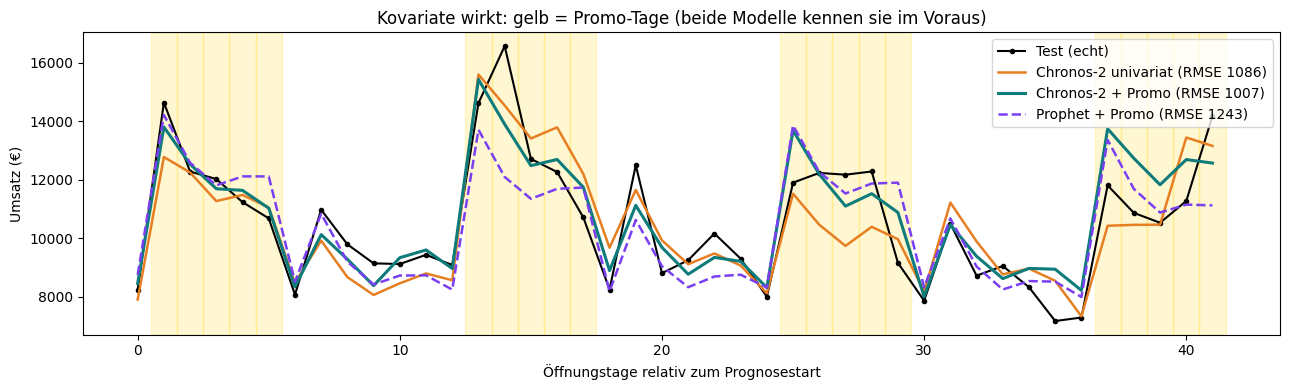

In [13]:
# --- 5.2 + KOVARIATE: der Promo-Kalender ist im Voraus bekannt -> wir geben ihn mit ---
context_cov = pd.DataFrame({'id': f'store_{store}', 'timestamp': cal_hist.index,
                            'target': ctx_nan,
                            'Promo': cal_hist['Promo'].fillna(0).to_numpy(dtype=float)})
future_cov  = pd.DataFrame({'id': f'store_{store}', 'timestamp': cal_test.index,
                            'Promo': cal_test['Promo'].fillna(0).to_numpy(dtype=float)})
pred_cov = pipe2.predict_df(context_cov, future_df=future_cov, prediction_length=H_cal,
                            quantile_levels=[0.1, 0.5, 0.9],
                            id_column='id', timestamp_column='timestamp', target='target')
med_c2_cov = pred_cov['0.5'].to_numpy()[open_pos]
m_c2_cov = print_metrics(y_test, med_c2_cov, 'Chronos-2 + Promo (Kovariate)')

# Fairer Gegner auf GLEICHEM Wissensstand: Prophet einfach + Promo-Regressor
# (kein Feiertagskalender - nur dasselbe Promo-Wissen wie Chronos-2)
m_pp = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m_pp.add_regressor('Promo')
m_pp.fit(pd.DataFrame({'ds': dates_train.values, 'y': y_train,
                       'Promo': df['Promo'].to_numpy(dtype=float)[:-H]}))
fc_pp = m_pp.predict(pd.DataFrame({'ds': dates_test.values,
                                   'Promo': df['Promo'].to_numpy(dtype=float)[-H:]}))
pred_prophet_promo = fc_pp['yhat'].to_numpy()
m_p_promo = print_metrics(y_test, pred_prophet_promo, 'Prophet + Promo (Regressor, fit)')

# Grafik: Promo-Tage schattieren, alle drei Prognosen vergleichen
promo_open = cal_test['Promo'].fillna(0).to_numpy(dtype=float)[open_pos]
x_fc = np.arange(H)
plt.figure(figsize=(13, 4))
for i in np.where(promo_open == 1)[0]:
    plt.axvspan(i - 0.5, i + 0.5, color='gold', alpha=0.18)
plt.plot(x_fc, y_test, color='black', marker='.', label='Test (echt)')
plt.plot(x_fc, med_c2_uni, color=C_MID, lw=1.8, label=f'Chronos-2 univariat (RMSE {m_c2_uni["RMSE"]:.0f})')
plt.plot(x_fc, med_c2_cov, color=C_C2, lw=2.2, label=f'Chronos-2 + Promo (RMSE {m_c2_cov["RMSE"]:.0f})')
plt.plot(x_fc, pred_prophet_promo, color=C_PROPHET, lw=1.8, ls='--',
         label=f'Prophet + Promo (RMSE {m_p_promo["RMSE"]:.0f})')
plt.title('Kovariate wirkt: gelb = Promo-Tage (beide Modelle kennen sie im Voraus)')
plt.xlabel('Öffnungstage relativ zum Prognosestart'); plt.ylabel('Umsatz (€)')
plt.legend(); plt.tight_layout(); plt.show()


**Was sehen wir?** Die Umsatzwellen folgen dem Promo-Rhythmus (gelb). Mit der Kovariate trifft Chronos-2 diese Wellen deutlich besser – das Zusatzwissen legt auf den Architektur-Sprung noch einmal messbar drauf (RMSE 1086 → 1007, −7 %).

Und der faire Vergleich: **Prophet bekommt dasselbe Promo-Wissen** (als Regressor, mit `fit()`). Auf gleichem Wissensstand liegen beide typischerweise nah beieinander – der Unterschied: Chronos-2 braucht dafür kein Training, nur eine Extra-Spalte in der Tabelle.


### 5.3 · Das Finale: Panel über mehrere Filialen vs. bestes Prophet-Modell

> 🟢 **In einfachen Worten:** Jetzt alles zusammen. Chronos-2 bekommt **mehrere Filialen in EINER Tabelle** (sie lernen voneinander = Cross-Learning) **plus** den Promo-Kalender. Dagegen tritt der **voll ausgebaute Prophet** an (deutsche Feiertage + Promo-Regressor, ein `fit()` pro Filiale). Bolt-small läuft einzeln als Bodenwert mit, Chronos-2 einzeln-univariat als fairer Zwischenschritt.
>
> Alle Filialen bekommen dasselbe Testfenster (die letzten 49 Kalendertage) und werden nur auf ihren Öffnungstagen benotet. Lücken in den Daten (Filiale 100 und 500 haben ein halbes Jahr Pause!) werden einfach zu NaN – Chronos steckt das weg.
>
> ⏱ Prophet braucht für die Filial-`fit()`s auf CPU ca. 1–2 Minuten.


In [14]:
# --- Schritt 1: pro Filiale die NaN-Kalenderreihe bauen ---
STORES_MV = [1097, 25, 100, 200, 500, 700]     # Liste änderbar; mehr Filialen = längere Laufzeit
H_MV = 49                                       # Kalendertage Testfenster (~7 Wochen)

stores_mv, ctx_rows, fut_rows = {}, [], []
for s in STORES_MV:
    r = train[train['Store'] == s].sort_values('Date')
    calx = r.set_index('Date')[['Sales', 'Open', 'Promo']].asfreq('D')
    calx['closed'] = (calx['Open'].fillna(0) == 0) | (calx['Sales'].fillna(0) == 0)
    calx['y'] = calx['Sales'].where(~calx['closed'])           # NaN an Schließtagen & in Lücken
    hist, test = calx.iloc[:-H_MV], calx.iloc[-H_MV:]
    pos = np.where(~test['closed'].to_numpy())[0]              # Öffnungstage im Testfenster
    if len(hist) < 200 or len(pos) < 20:
        print(f'Filiale {s} übersprungen'); continue
    stores_mv[s] = (hist, test, pos)
    ctx_rows.append(pd.DataFrame({'id': f'store_{s}', 'timestamp': hist.index,
                                  'target': hist['y'].to_numpy(dtype=float),
                                  'Promo': hist['Promo'].fillna(0).to_numpy(dtype=float)}))
    fut_rows.append(pd.DataFrame({'id': f'store_{s}', 'timestamp': test.index,
                                  'Promo': test['Promo'].fillna(0).to_numpy(dtype=float)}))

context_mv = pd.concat(ctx_rows, ignore_index=True)            # ALLE Filialen untereinander
future_mv  = pd.concat(fut_rows, ignore_index=True)
print(f'{len(stores_mv)} Filialen im Panel, Testfenster = {H_MV} Kalendertage')

# --- Schritt 2: EIN Aufruf für alle Filialen (Panel + Promo) ---
pred_mv = pipe2.predict_df(context_mv, future_df=future_mv, prediction_length=H_MV,
                           quantile_levels=[0.5],
                           id_column='id', timestamp_column='timestamp', target='target')
print('Panel-Forecast fertig.')


6 Filialen im Panel, Testfenster = 49 Kalendertage
Panel-Forecast fertig.


14:49:05 - cmdstanpy - INFO - Chain [1] start processing
14:49:05 - cmdstanpy - INFO - Chain [1] done processing


Filiale 1097 fertig (49 Test-Öffnungstage)


14:49:06 - cmdstanpy - INFO - Chain [1] start processing
14:49:06 - cmdstanpy - INFO - Chain [1] done processing


Filiale 25 fertig (42 Test-Öffnungstage)


14:49:06 - cmdstanpy - INFO - Chain [1] start processing
14:49:06 - cmdstanpy - INFO - Chain [1] done processing


...

Filiale 200 fertig (42 Test-Öffnungstage)


14:49:07 - cmdstanpy - INFO - Chain [1] start processing
14:49:07 - cmdstanpy - INFO - Chain [1] done processing


Filiale 500 fertig (42 Test-Öffnungstage)


14:49:07 - cmdstanpy - INFO - Chain [1] start processing
14:49:07 - cmdstanpy - INFO - Chain [1] done processing


Filiale 700 fertig (42 Test-Öffnungstage)

RMSE je Filiale (kleiner = besser)
            Bolt-small (einzeln)  Chronos-2 (einzeln)  \
Filiale                                                 
1097                      1319.3                776.8   
25                        1685.3               1085.9   
100                       1415.4               1014.7   
200                       1339.9                948.1   
500                       1046.6                976.8   
700                        969.0                481.9   
Ø (Mittel)                1295.9                880.7   
Median                    1329.6                962.4   

            Chronos-2 (Panel+Promo)  Prophet (Feiertage+Promo)  
Filiale                                                         
1097                          692.8                      713.9  
25                           1007.3                     1240.4  
100                           818.8                     3624.6  
200                       

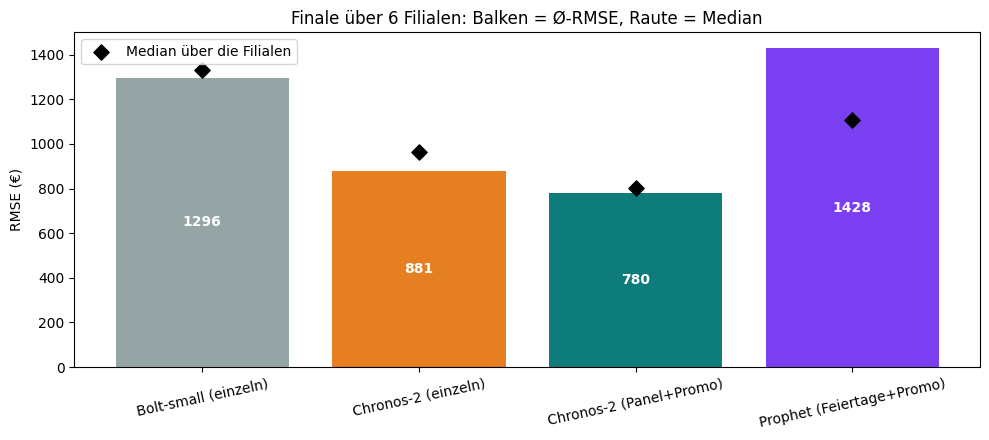

In [15]:
# --- Schritt 3: Konkurrenten je Filiale + Auswertung ---
def prophet_full(hist, test, pos):
    """Bestes Prophet-Modell: DE-Feiertage + Promo-Regressor (ein fit() pro Filiale)."""
    tro = hist[~hist['closed']]                                # Prophet: nur echte Öffnungstage
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    m.add_country_holidays(country_name='DE')
    m.add_regressor('Promo')
    m.fit(pd.DataFrame({'ds': tro.index, 'y': tro['Sales'].values,
                        'Promo': tro['Promo'].fillna(0).values}))
    fc = m.predict(pd.DataFrame({'ds': test.index[pos],
                                 'Promo': test['Promo'].fillna(0).to_numpy()[pos]}))
    return fc['yhat'].to_numpy()

rows_mv, preds_mv = [], {}
for s, (hist, test, pos) in stores_mv.items():
    y_te = test['Sales'].to_numpy(dtype=float)[pos]
    # a) Bolt-small einzeln (NaN-Fütterung, aber ohne Promo/Panel) -> Bodenwert
    q, _ = pipe.predict_quantiles(inputs=torch.tensor(hist['y'].to_numpy(dtype=float),
                                                      dtype=torch.float32),
                                  prediction_length=H_MV, quantile_levels=[0.5])
    p_bolt = q[0, :, 0].numpy()[pos]
    # b) Chronos-2 einzeln, univariat (fairer Zwischenschritt)
    p_uni = pipe2.predict_df(pd.DataFrame({'id': f's{s}', 'timestamp': hist.index,
                                           'target': hist['y'].to_numpy(dtype=float)}),
                             prediction_length=H_MV, quantile_levels=[0.5],
                             id_column='id', timestamp_column='timestamp', target='target')
    p_c2uni = p_uni['0.5'].to_numpy()[pos]
    # c) Chronos-2 Panel + Promo (aus Schritt 2)
    p_c2mv = pred_mv.loc[pred_mv['id'] == f'store_{s}', '0.5'].to_numpy()[pos]
    # d) Prophet voll ausgebaut
    p_prof = prophet_full(hist, test, pos)
    # Vorhersagen aufheben (für die Tages-Grafik unten) + RMSE berechnen
    preds_mv[s] = {'Datum': test.index[pos], 'echt': y_te,
                   'Bolt-small (einzeln)': p_bolt, 'Chronos-2 (einzeln)': p_c2uni,
                   'Chronos-2 (Panel+Promo)': p_c2mv, 'Prophet (Feiertage+Promo)': p_prof}
    rows_mv.append({'Filiale': s, **{name: np.sqrt(mean_squared_error(y_te, arr))
                                     for name, arr in preds_mv[s].items()
                                     if name not in ('Datum', 'echt')}})
    print(f'Filiale {s} fertig ({len(pos)} Test-Öffnungstage)')

base_mv = pd.DataFrame(rows_mv).set_index('Filiale')
mv = base_mv.copy()
mv.loc['Ø (Mittel)'] = base_mv.mean()      # empfindlich gegen Ausreißer
mv.loc['Median']     = base_mv.median()    # robust gegen Ausreißer
print(); print('RMSE je Filiale (kleiner = besser)'); print(mv.round(1))

# Finale Grafik: Balken = Ø, schwarze Raute = Median (robust gegen Ausreißer)
means_row, median_row = mv.loc['Ø (Mittel)'], mv.loc['Median']
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#95A5A6', C_MID, C_C2, C_PROPHET]
bars = ax.bar(means_row.index, means_row.values, color=colors)
for b, v in zip(bars, means_row.values):
    ax.text(b.get_x() + b.get_width()/2, v/2, f'{v:.0f}', ha='center', va='center',
            color='white', fontweight='bold')
ax.scatter(median_row.index, median_row.values, color='black', marker='D', s=60,
           zorder=3, label='Median über die Filialen')
ax.set_ylabel('RMSE (€)')
ax.set_title(f'Finale über {len(stores_mv)} Filialen: Balken = Ø-RMSE, Raute = Median')
ax.legend(); plt.xticks(rotation=12); plt.tight_layout(); plt.show()


### 📊 Die Umsätze über die Testtage – wo genau gewinnt und verliert wer?

Zahlen sind gut, Linien sind besser: pro Filiale die echten Umsätze gegen alle vier Prognosen. `SHOW_STORES` ist änderbar – voreingestellt sind die zwei Gegenpole der Geschichte: die **„gesunde" Filiale 500** (saubere Historie – hier ist der voll ausgebaute Prophet absolut konkurrenzfähig) und die **lehrreiche Filiale 100** (halbes Jahr Pause in den Daten – hier entgleist Prophets `fit()`).


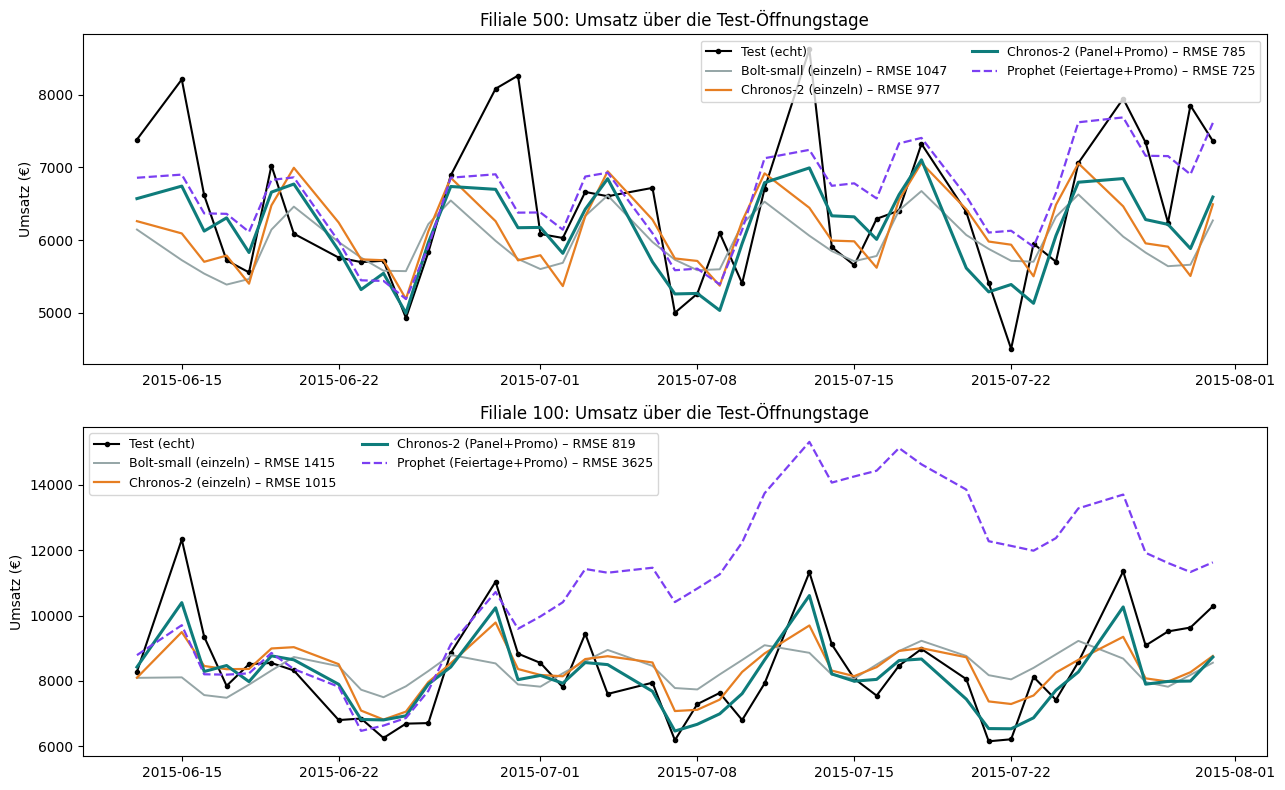

In [16]:
SHOW_STORES = [500, 100]                   # <- anpassen, z. B. [25, 1097, 700]

model_style = {
    'Bolt-small (einzeln)':      dict(color='#95A5A6', lw=1.4),
    'Chronos-2 (einzeln)':       dict(color=C_MID,     lw=1.6),
    'Chronos-2 (Panel+Promo)':   dict(color=C_C2,      lw=2.2),
    'Prophet (Feiertage+Promo)': dict(color=C_PROPHET, lw=1.6, ls='--'),
}
fig, axes = plt.subplots(len(SHOW_STORES), 1, figsize=(13, 4 * len(SHOW_STORES)))
axes = np.atleast_1d(axes)
for ax, s in zip(axes, SHOW_STORES):
    p = preds_mv[s]
    ax.plot(p['Datum'], p['echt'], color='black', marker='.', label='Test (echt)')
    for name, style in model_style.items():
        ax.plot(p['Datum'], p[name], label=f'{name} – RMSE {base_mv.loc[s, name]:.0f}', **style)
    ax.set_title(f'Filiale {s}: Umsatz über die Test-Öffnungstage')
    ax.set_ylabel('Umsatz (€)'); ax.legend(fontsize=9, ncol=2)
plt.tight_layout(); plt.show()


**Was sehen wir?** (mit der voreingestellten Filialauswahl)

- **Chronos-2 Panel + Promo** (türkis) gewinnt im Durchschnitt UND beim Median – ohne Feiertagskalender, ohne Feature-Engineering, ohne ein einziges `fit()`, mit EINEM Aufruf für alle Filialen.
- **Prophet voll** (lila) landet im Ø sogar hinten – aber Vorsicht bei der Interpretation! Der Median und die Tages-Grafik zeigen: Das Debakel kommt fast komplett von **einer** Filiale (100). Die hat ein **halbes Jahr Pause** in den Daten – Prophet lernt per `fit()` Trend und Saisonalität aus der gebrochenen Historie und extrapoliert daneben. Auf „gesunden" Filialen (z. B. 500) ist Prophet voll absolut konkurrenzfähig.
- **Chronos-2 einzeln** (orange) schlägt Prophet voll auf den meisten Filialen schon ohne jedes Zusatzwissen – zero-shot schaut vor allem auf den jüngsten Kontext und ist dadurch **robust gegen Brüche** in der Historie.
- **Bolt einzeln** (grau) bleibt der Bodenwert.

**Die eigentliche Lektion:** „Mit allem drum und dran" schützt nicht. Trainierte Modelle **erben jeden Bruch** in ihren Trainingsdaten; Foundation-Modelle sind out of the box robuster. Prophets Domänenwissen zahlt sich nur aus, wenn die Historie sauber gepflegt ist.

> **Einordnung:** *Viele* Filialen, wenig Aufwand, unbekannte Datenqualität → Chronos-2. *Einzelne, saubere* Serien mit gepflegtem, erklärbarem Domänenwissen → Prophet. Ausreißer immer per Median UND Tages-Grafik gegenchecken – gern andere `STORES_MV` testen.


---
## 6 · Zum Schluss: Was kann KEIN Modell? Der Corona-Schock

> 🟢 **In einfachen Worten:** Europäische Flugverkehrsdaten, Prognosestart Anfang 2020. Kein Modell der Welt konnte den Corona-Einbruch aus der Historie vorhersehen – Chronos auch nicht. Wichtig, um Forecasts richtig einzuordnen: Sie schreiben Muster fort, sie kennen keine Nachrichten.


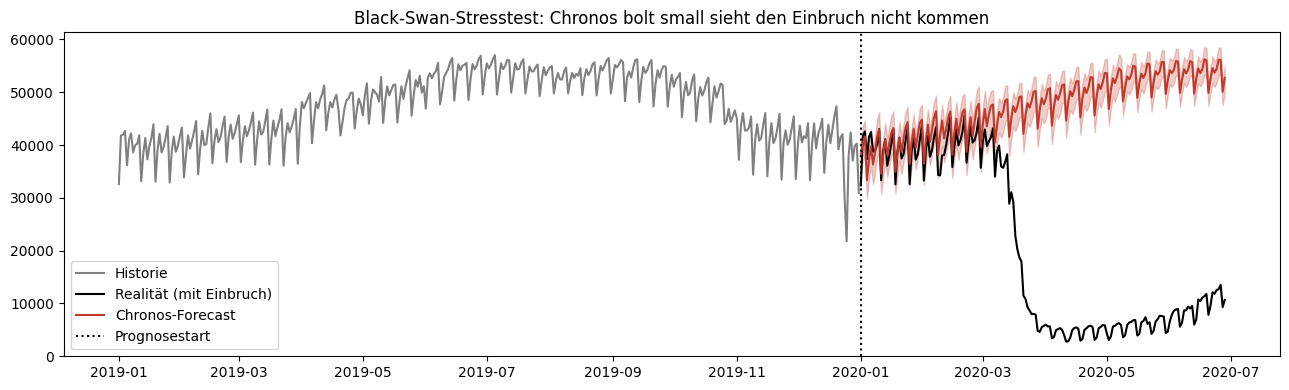

In [17]:
df_flights = pd.read_csv('../data/flights.csv', parse_dates=['FLT_DATE'])
daily = df_flights.groupby('FLT_DATE')['FLT_TOT_1'].sum().sort_index()
if daily.index.tz is not None:
    daily.index = daily.index.tz_localize(None)
y_f = daily.to_numpy(dtype=float)

# Kontext: alles VOR dem Bruch (Anfang 2020). Forecast über den Bruch hinweg.
cut = daily.index.get_indexer([pd.Timestamp('2020-01-01')], method='nearest')[0]
Hf = 180
ctx_f, true_f = y_f[:cut], y_f[cut:cut + Hf]

q, _ = pipe.predict_quantiles(inputs=torch.tensor(ctx_f, dtype=torch.float32),
                              prediction_length=Hf, quantile_levels=[0.1, 0.5, 0.9])
med_f, lo_f, hi_f = q[0, :, 1].numpy(), q[0, :, 0].numpy(), q[0, :, 2].numpy()

start = max(0, cut - 365)
plt.figure(figsize=(13, 4))
plt.plot(daily.index[start:cut], y_f[start:cut], color='gray', label='Historie')
plt.plot(daily.index[cut:cut + Hf], true_f, color='black', label='Realität (mit Einbruch)')
plt.plot(daily.index[cut:cut + Hf], med_f, color=C_BAD, label='Chronos-Forecast')
plt.fill_between(daily.index[cut:cut + Hf], lo_f, hi_f, color=C_BAD, alpha=0.25)
plt.axvline(daily.index[cut], color='k', ls=':', label='Prognosestart')
plt.title('Black-Swan-Stresstest: Chronos bolt small sieht den Einbruch nicht kommen')
plt.legend(); plt.tight_layout(); plt.show()


---
## 7 · Fazit – die Take-aways für den Vortrag

1. **Chronos liest Werte, kein Datum.** Schließtage niemals als 0 füttern – **als NaN maskieren** lassen. Vorsicht beim Kompaktieren: Es kann den Kalender-Takt verzerren (Woche = mal 6, mal 5 Schritte) und war bei uns sogar schlechter als die Nullen.
2. **Stellschrauben-Ranking auf Rossmann:** Fütterung/Datenaufbereitung ≫ Kontextlänge (hat ein Optimum) > Horizont kurz halten > Modellgröße (bringt wenig, kostet Zeit).
3. **Generation schlägt Größe – und Zusatzwissen legt nach:** Der größte Einzelsprung kam vom Wechsel Bolt → **Chronos-2** (RMSE −36 % bei gleichem Wissensstand – neue Architektur & Trainingsdaten, nicht mehr Parameter). Promo-Kovariate (−7 %) und Panel (−11 % im Finale) holen darauf noch einmal messbar mehr heraus – beides kann erst Chronos-2.
4. **Chronos-2 Panel + Kovariate ≈ voll ausgebauter Prophet** – aber zero-shot, ohne Feature-Engineering, ein Aufruf für alle Filialen. Prophet bleibt die Wahl, wenn Erklärbarkeit und gepflegtes Domänenwissen zählen.
5. **Demut zum Schluss:** Strukturbrüche (Corona) sieht kein Modell. Forecasts schreiben Muster fort – Verantwortung bleibt beim Menschen.


---
## 🧰 Anhang · Spickzettel: Pipelines & Kovariaten je Chronos-Variante

### A.1 Chronos (t5, 1. Generation) – Sampling-Modell
```python
from chronos import BaseChronosPipeline   # erkennt am Checkpoint die Variante
import torch

pipe_t5 = BaseChronosPipeline.from_pretrained('amazon/chronos-t5-small', device_map='cpu')
q, mean = pipe_t5.predict_quantiles(
    inputs=torch.tensor(ctx_nan, dtype=torch.float32),   # EINE Serie als Tensor
    prediction_length=42, quantile_levels=[0.1, 0.5, 0.9])
```
- Input = nackte Zahlenfolge, kein Datum, keine Zusatzspalten.
- Prognose durch **Sampling** (viele Zukunftspfade würfeln) → Median ≠ Mean.
- **Kovariaten wie Promo: NICHT möglich** – das Modell sieht nur die eine Zahlenfolge.

### A.2 Chronos-Bolt – direkte Quantil-Köpfe
```python
pipe = BaseChronosPipeline.from_pretrained('amazon/chronos-bolt-small', device_map='cpu')
q, _ = pipe.predict_quantiles(inputs=torch.tensor(ctx_nan, dtype=torch.float32),
                              prediction_length=42, quantile_levels=[0.1, 0.5, 0.9])
```
- **Gleiche Fabrik-Klasse** `BaseChronosPipeline` – sie liefert je nach Checkpoint intern eine `ChronosPipeline` (t5) oder `ChronosBoltPipeline` (Bolt) zurück. Der Aufruf-Code bleibt identisch.
- Kein Sampling, sondern **direkte Quantil-Köpfe** → viel schneller; „mean" ist hier nur ein Platzhalter für den Median.
- **Kovariaten & Panel: ebenfalls NICHT möglich** – auch Bolt bleibt strikt univariat.

### A.3 Chronos-2 – DataFrame-API, Kovariaten & Panel eingebaut
```python
from chronos import Chronos2Pipeline
pipe2 = Chronos2Pipeline.from_pretrained('amazon/chronos-2', device_map='cpu')

# Kontext = lange Tabelle. JEDE Spalte neben id/timestamp/target ist automatisch eine Kovariate:
context = pd.DataFrame({'id': 'store_25', 'timestamp': hist.index,
                        'target': ctx_nan,               # NaN an Schließtagen!
                        'Promo': hist['Promo'].values})  # <- Kovariate, Vergangenheit
# Zukunft = im Voraus bekannte Kovariaten-Werte im Prognosefenster (OHNE target):
future = pd.DataFrame({'id': 'store_25', 'timestamp': test.index,
                       'Promo': test['Promo'].values})   # <- Kovariate, Zukunft
pred = pipe2.predict_df(context, future_df=future, prediction_length=49,
                        quantile_levels=[0.1, 0.5, 0.9],
                        id_column='id', timestamp_column='timestamp', target='target')
```
- **Kovariate einbauen = eine Spalte anhängen** – in `context` (Historie) und, weil der Promo-Plan im Voraus feststeht, in `future_df` (Prognosefenster). Kein `add_regressor`, kein Feature-Engineering (Kap. 5.2).
- **Panel / Cross-Learning = mehrere `id`s untereinander** in derselben Tabelle → EIN `predict_df`-Aufruf für alle Filialen (Kap. 5.3).

### A.4 Warum kann das NUR Chronos-2? → In-Context Learning & Group Attention
Zwei Schlüsselbegriffe aus dem Chronos-2-Paper (Ansari et al., `literature/chronos2.txt` bzw. `AnsariEtAl_Chronos2.pdf`):

- **In-Context Learning (ICL):** Chronos-2 „lernt" allein aus dem, was man ihm im Kontext mitgibt – ohne `fit()`, ohne ein einziges Gewichts-Update. Deshalb wirken Promo-Spalte und Nachbar-Filialen **sofort und zero-shot**.
- **Group Attention:** Jeder Transformer-Block wechselt zwischen zwei Attention-Arten: **Time Attention** bündelt Information *innerhalb* einer Serie über die Zeit; **Group Attention** bündelt Information *zwischen allen Serien einer Gruppe* zum jeweils gleichen Zeitpunkt – also zwischen `target`, Kovariaten und anderen Filialen. Group Attention ist laut Paper der Mechanismus, der ICL über Serien hinweg (Kovariaten, multivariat, Panel) überhaupt erst ermöglicht.
- Chronos-t5 und Bolt besitzen **nur** die Zeit-Dimension (keine Group Attention) – darum bleiben sie strikt univariat.

### A.5 Alles auf einen Blick

| | Chronos (t5) | Chronos-Bolt | Chronos-2 |
|---|---|---|---|
| Pipeline | `BaseChronosPipeline` → `ChronosPipeline` | `BaseChronosPipeline` → `ChronosBoltPipeline` | `Chronos2Pipeline` |
| Input | 1 Serie als Tensor | 1 Serie als Tensor | DataFrame: `id`, `timestamp`, `target` + beliebige Kovariaten-Spalten |
| Prognose-Aufruf | `predict_quantiles(...)` | `predict_quantiles(...)` | `predict_df(context, future_df=...)` |
| Prognose-Art | Sampling (Median ≠ Mean) | direkte Quantile („mean" = Median) | direkte Quantile |
| Kovariaten (Promo) | ❌ | ❌ | ✅ Spalte in `context` + `future_df` |
| Panel / Cross-Learning | ❌ | ❌ | ✅ mehrere `id`s, ein Aufruf |
| Mechanismus | Time Attention | Time Attention | Time + **Group Attention** → **In-Context Learning** |
